In [1]:
import pandas as pd
df_prices = pd.read_csv('all_price_history.csv')
df_summary = pd.read_csv('download_summary.csv')

In [2]:
df_prices.columns

Index(['t', 'p', 'timestamp', 'price', 'token_id', 'market_id', 'question',
       'market_slug', 'end_date', 'hours_to_resolution'],
      dtype='object')

In [3]:
df_summary.columns

Index(['market_id', 'question', 'token_id', 'status', 'n_rows'], dtype='object')

In [4]:
df_prices.head()


,t,p,timestamp,price,token_id,market_id,question,market_slug,end_date,hours_to_resolution
0,1771764018,0.2635,2026-02-22 12:40:18+00:00,0.2635,7546712961590831958303147464265888547913563043...,531202,BitBoy convicted?,bitboy-convicted,2026-03-31T12:00:00Z,887.328333
1,1771764618,0.2635,2026-02-22 12:50:18+00:00,0.2635,7546712961590831958303147464265888547913563043...,531202,BitBoy convicted?,bitboy-convicted,2026-03-31T12:00:00Z,887.161667
2,1771765220,0.2635,2026-02-22 13:00:20+00:00,0.2635,7546712961590831958303147464265888547913563043...,531202,BitBoy convicted?,bitboy-convicted,2026-03-31T12:00:00Z,886.994444
3,1771765819,0.2635,2026-02-22 13:10:19+00:00,0.2635,7546712961590831958303147464265888547913563043...,531202,BitBoy convicted?,bitboy-convicted,2026-03-31T12:00:00Z,886.828056
4,1771766434,0.2635,2026-02-22 13:20:34+00:00,0.2635,7546712961590831958303147464265888547913563043...,531202,BitBoy convicted?,bitboy-convicted,2026-03-31T12:00:00Z,886.657222


In [5]:
df_summary.head()


,market_id,question,token_id,status,n_rows
0,531202,BitBoy convicted?,7546712961590831958303147464265888547913563043...,ok,4010
1,540816,Russia-Ukraine Ceasefire before GTA VI?,8501497159083948713316135768103773293754490207...,ok,4025
2,540817,New Rihanna Album before GTA VI?,9802249026969240999812649612759703249033407008...,ok,4015
3,540818,New Playboi Carti Album before GTA VI?,8827504006008477337655718797221526751304984864...,ok,4025
4,540819,Will Jesus Christ return before GTA VI?,9043581125366557801495738082650599253005407769...,ok,4018


In [6]:
import requests

# Vediamo cosa offre la Gamma API per i mercati
url = "https://gamma-api.polymarket.com/markets"
params = {
    "closed": "true",  # mercati chiusi
    "limit": 5
}

resp = requests.get(url, params=params)
print(resp.status_code)
print(resp.json()[0].keys())  # vediamo i campi disponibili

200
dict_keys(['id', 'question', 'conditionId', 'slug', 'twitterCardImage', 'endDate', 'category', 'liquidity', 'image', 'icon', 'description', 'outcomes', 'outcomePrices', 'volume', 'active', 'marketType', 'closed', 'marketMakerAddress', 'updatedBy', 'createdAt', 'updatedAt', 'closedTime', 'mailchimpTag', 'archived', 'restricted', 'volumeNum', 'liquidityNum', 'endDateIso', 'hasReviewedDates', 'readyForCron', 'volume24hr', 'volume1wk', 'volume1mo', 'volume1yr', 'clobTokenIds', 'fpmmLive', 'volume1wkAmm', 'volume1moAmm', 'volume1yrAmm', 'volume1wkClob', 'volume1moClob', 'volume1yrClob', 'events', 'creator', 'ready', 'funded', 'cyom', 'competitive', 'pagerDutyNotificationEnabled', 'approved', 'rewardsMinSize', 'rewardsMaxSpread', 'spread', 'oneDayPriceChange', 'oneHourPriceChange', 'oneWeekPriceChange', 'oneMonthPriceChange', 'oneYearPriceChange', 'lastTradePrice', 'bestBid', 'bestAsk', 'clearBookOnStart', 'manualActivation', 'negRiskOther', 'umaResolutionStatuses', 'pendingDeployment', 

In [7]:
import json

resp = requests.get(url, params=params)
market = resp.json()[0]

# Campi utili per il nostro scopo
campi_utili = ['question', 'closed', 'closedTime', 'endDate', 'volume', 
               'liquidity', 'lastTradePrice', 'outcomePrices', 'outcomes',
               'category', 'clobTokenIds']

for k in campi_utili:
    print(f"{k}: {market[k]}")

question: Will Joe Biden get Coronavirus before the election?
closed: True
closedTime: 2020-11-02 16:31:01+00
endDate: 2020-11-04T00:00:00Z
volume: 32257.445115
liquidity: 0
lastTradePrice: 0
outcomePrices: ["0", "0"]
outcomes: ["Yes", "No"]
category: US-current-affairs
clobTokenIds: ["53135072462907880191400140706440867753044989936304433583131786753949599718775", "60869871469376321574904667328762911501870754872924453995477779862968218702336"]


In [8]:
# Scarichiamo più mercati chiusi e teniamo solo quelli ben risolti
params = {
    "closed": "true",
    "limit": 100
}

resp = requests.get(url, params=params)
markets = resp.json()

# Filtro: mercati binari risolti (un outcome a 1, uno a 0)
resolved = []
for m in markets:
    try:
        prices = [float(p) for p in m['outcomePrices']]
        if sorted(prices) == [0.0, 1.0]:  # risolto chiaramente
            resolved.append(m)
    except:
        continue

print(f"Totale scaricati: {len(markets)}")
print(f"Risolti chiaramente: {len(resolved)}")
print(f"\nEsempio: {resolved[0]['question']}")
print(f"Outcomes: {resolved[0]['outcomes']}")
print(f"Prices: {resolved[0]['outcomePrices']}")
print(f"Volume: {resolved[0]['volume']}")

Totale scaricati: 100
Risolti chiaramente: 0


IndexError: list index out of range

In [9]:
# Vediamo come sono distribuiti i prezzi nei mercati chiusi
for m in markets[:10]:
    try:
        prices = m['outcomePrices']
        print(f"{m['question'][:50]} -> {prices}")
    except:
        continue

Will Joe Biden get Coronavirus before the election -> ["0", "0"]
Will Airbnb begin publicly trading before Jan 1, 2 -> ["0", "0"]
Will a new Supreme Court Justice be confirmed befo -> ["0", "0"]
Will Kim Kardashian and Kanye West divorce before  -> ["0.000001011082052522541417308141468657552", "0.9999989889179474774585826918585313"]
Will Coinbase begin publicly trading before Jan 1, -> ["0.000001024519509568169644816863666886675", "0.9999989754804904318303551831363331"]
What will the price of Bitcoin be on November 4th, -> ["0", "0"]
Will Trump win the 2020 U.S. presidential election -> ["0.00000004364303498046286702037228176483457", "0.9999999563569650195371329796277182"]
Will there be an Emergency Use Authorization (EUA) -> ["0", "0"]
What will the total value locked (TVL) in DeFi be  -> ["0.5843311669077693146635445446077281", "0.4156688330922306853364554553922719"]
What will the USD price of Filecoin ($FIL) be on N -> ["0.4988929462743076960451117056339252", "0.50110705372569230395

In [10]:
# Filtro con soglia: un outcome > 0.99, l'altro < 0.01
resolved = []
for m in markets:
    try:
        prices = [float(p) for p in m['outcomePrices']]
        if len(prices) == 2 and (max(prices) > 0.99 and min(prices) < 0.01):
            resolved.append(m)
    except:
        continue

print(f"Risolti con soglia 0.99: {len(resolved)}")
for m in resolved[:5]:
    prices = [float(p) for p in m['outcomePrices']]
    print(f"  {m['question'][:60]} -> {[round(p,4) for p in prices]}")

Risolti con soglia 0.99: 0


In [12]:
# Vediamo tutti i max prices per capire la distribuzione
for m in markets:
    try:
        prices = [float(p) for p in m['outcomePrices']]
        if len(prices) == 2:
            print(f"{round(max(prices), 4)} | {m['question'][:55]}")
    except:
        continue

In [13]:
for m in markets[:10]:
    print(type(m['outcomePrices']), repr(m['outcomePrices']))

<class 'str'> '["0", "0"]'
<class 'str'> '["0", "0"]'
<class 'str'> '["0", "0"]'
<class 'str'> '["0.000001011082052522541417308141468657552", "0.9999989889179474774585826918585313"]'
<class 'str'> '["0.000001024519509568169644816863666886675", "0.9999989754804904318303551831363331"]'
<class 'str'> '["0", "0"]'
<class 'str'> '["0.00000004364303498046286702037228176483457", "0.9999999563569650195371329796277182"]'
<class 'str'> '["0", "0"]'
<class 'str'> '["0.5843311669077693146635445446077281", "0.4156688330922306853364554553922719"]'
<class 'str'> '["0.4988929462743076960451117056339252", "0.5011070537256923039548882943660748"]'


In [14]:
import json

resolved = []
for m in markets:
    try:
        prices = [float(p) for p in json.loads(m['outcomePrices'])]
        if len(prices) == 2 and (max(prices) > 0.99 and min(prices) < 0.01):
            resolved.append(m)
    except:
        continue

print(f"Risolti con soglia 0.99: {len(resolved)}")
for m in resolved[:5]:
    prices = [float(p) for p in json.loads(m['outcomePrices'])]
    print(f"  {m['question'][:60]} -> {[round(p,4) for p in prices]}")

Risolti con soglia 0.99: 45
  Will Kim Kardashian and Kanye West divorce before Jan 1, 202 -> [0.0, 1.0]
  Will Coinbase begin publicly trading before Jan 1, 2021? -> [0.0, 1.0]
  Will Trump win the 2020 U.S. presidential election? -> [0.0, 1.0]
  How many confirmed Coronavirus cases will there be at EOY in -> [1.0, 0.0]
  Will there be a federal charge filed against Hunter Biden be -> [0.0, 1.0]


In [15]:
# Scarichiamo più pagine di mercati chiusi e filtriamo i risolti
all_resolved = []
offset = 0
limit = 100

while offset < 1000:  # max 10 pagine per ora
    params = {
        "closed": "true",
        "limit": limit,
        "offset": offset
    }
    resp = requests.get(url, params=params)
    batch = resp.json()
    
    if not batch:
        print(f"Fine dati all'offset {offset}")
        break
    
    for m in batch:
        try:
            prices = [float(p) for p in json.loads(m['outcomePrices'])]
            if len(prices) == 2 and max(prices) > 0.99 and min(prices) < 0.01:
                all_resolved.append(m)
        except:
            continue
    
    print(f"Offset {offset}: batch={len(batch)}, risolti totali={len(all_resolved)}")
    offset += limit

Offset 0: batch=100, risolti totali=45
Offset 100: batch=100, risolti totali=132
Offset 200: batch=100, risolti totali=214
Offset 300: batch=100, risolti totali=310
Offset 400: batch=100, risolti totali=403
Offset 500: batch=100, risolti totali=491
Offset 600: batch=100, risolti totali=586
Offset 700: batch=100, risolti totali=676
Offset 800: batch=100, risolti totali=763
Offset 900: batch=100, risolti totali=856


In [16]:
all_resolved = []
offset = 0
limit = 100

while True:
    params = {
        "closed": "true",
        "limit": limit,
        "offset": offset
    }
    resp = requests.get(url, params=params)
    batch = resp.json()
    
    if not batch:
        print(f"Fine dati all'offset {offset}")
        break
    
    for m in batch:
        try:
            prices = [float(p) for p in json.loads(m['outcomePrices'])]
            if len(prices) == 2 and max(prices) > 0.99 and min(prices) < 0.01:
                all_resolved.append(m)
        except:
            continue
    
    offset += limit
    if offset % 500 == 0:
        print(f"Offset {offset}: risolti totali={len(all_resolved)}")
    
    if offset >= 5000:
        print("Raggiunto limite 5000")
        break

print(f"\nTotale mercati risolti: {len(all_resolved)}")

Offset 500: risolti totali=403
Offset 1000: risolti totali=856
Offset 1500: risolti totali=1346
Offset 2000: risolti totali=1836
Offset 2500: risolti totali=2321
Offset 3000: risolti totali=2819
Offset 3500: risolti totali=3318
Offset 4000: risolti totali=3817
Offset 4500: risolti totali=4286
Offset 5000: risolti totali=4751
Raggiunto limite 5000

Totale mercati risolti: 4751


In [18]:
import pandas as pd

# Campi utili per il trading
campi = ['id', 'question', 'category', 'closedTime', 'endDate', 
         'volume', 'liquidity', 'outcomePrices', 'outcomes', 
         'clobTokenIds', 'lastTradePrice', 'spread']

df_markets = pd.DataFrame(all_resolved)[campi].copy()

# Convertiamo i tipi
df_markets['volume'] = df_markets['volume'].astype(float)
df_markets['closedTime'] = pd.to_datetime(df_markets['closedTime'], utc=True)

print(df_markets.shape)
print(df_markets.dtypes)
print(f"\nVolume totale: ${df_markets['volume'].sum():,.0f}")
print(f"\nCategorie:\n{df_markets['category'].value_counts().head(10)}")

ValueError: time data "2024-07-18 00:10:37.491895+00" doesn't match format "%Y-%m-%d %H:%M:%S%z", at position 1832. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [19]:
df_markets = pd.DataFrame(all_resolved)[campi].copy()

df_markets['volume'] = df_markets['volume'].astype(float)
df_markets['closedTime'] = pd.to_datetime(df_markets['closedTime'], format='mixed', utc=True)

print(df_markets.shape)
print(f"Volume totale: ${df_markets['volume'].sum():,.0f}")
print(f"\nCategorie:\n{df_markets['category'].value_counts().head(10)}")

# Salviamo
df_markets.to_csv('resolved_markets.csv', index=False)
print("\nSalvato: resolved_markets.csv")

(4751, 12)
Volume totale: $248,631,112

Categorie:
category
Sports                2491
Crypto                 328
US-current-affairs     321
Pop-Culture            194
Coronavirus            145
Business               133
NBA Playoffs           124
NFTs                   106
Chess                   70
Global Politics         57
Name: count, dtype: int64

Salvato: resolved_markets.csv


In [20]:
# CSV essenziale: teniamo solo ciò che serve per il price history
df_export = df_markets[['id', 'question', 'category', 'closedTime', 
                          'volume', 'clobTokenIds']].copy()

# clobTokenIds è una stringa JSON, la teniamo così per ora
print(df_export.head(3))
print(f"\nShape: {df_export.shape}")

df_export.to_csv('markets_for_pricehistory.csv', index=False)
print("Salvato: markets_for_pricehistory.csv")

   id                                           question            category  \
0  19  Will Kim Kardashian and Kanye West divorce bef...        Pop-Culture    
1  20  Will Coinbase begin publicly trading before Ja...              Crypto   
2  40  Will Trump win the 2020 U.S. presidential elec...  US-current-affairs   

                 closedTime        volume  \
0 2021-01-02 21:35:34+00:00  2.206748e+04   
1 2021-01-02 21:43:06+00:00  1.168034e+05   
2 2020-11-09 17:55:41+00:00  1.080260e+07   

                                        clobTokenIds  
0  ["44854687978432708053619076885850331050601341...  
1  ["36272374199536229966445059644094050673269921...  
2  ["44804726753601178293652604511461891232965799...  

Shape: (4751, 6)
Salvato: markets_for_pricehistory.csv


In [21]:
# Verifica: controlliamo closed e outcomePrices su tutti
print("Valori 'closed' unici:", pd.DataFrame(all_resolved)['closed'].unique())
print("Valori 'active' unici:", pd.DataFrame(all_resolved)['active'].unique())

# Esempio del primo mercato
m = all_resolved[0]
print(f"\nQuestion: {m['question']}")
print(f"closed: {m['closed']}")
print(f"active: {m['active']}")
print(f"closedTime: {m['closedTime']}")
print(f"outcomePrices: {m['outcomePrices']}")

Valori 'closed' unici: [ True]
Valori 'active' unici: [ True]

Question: Will Kim Kardashian and Kanye West divorce before Jan 1, 2021?
closed: True
active: True
closedTime: 2021-01-02 21:35:34+00
outcomePrices: ["0.000001011082052522541417308141468657552", "0.9999989889179474774585826918585313"]


In [22]:
# Prendiamo il clobTokenId del primo mercato (il token "Yes")
first_market = all_resolved[0]
token_ids = json.loads(first_market['clobTokenIds'])
token_yes = token_ids[0]

print(f"Mercato: {first_market['question']}")
print(f"Token YES: {token_yes}")

# CLOB API - price history
clob_url = "https://clob.polymarket.com/prices-history"
params = {
    "market": token_yes,
    "interval": "1d",  # candele giornaliere
    "fidelity": 100
}

resp = requests.get(clob_url, params=params)
print(f"\nStatus: {resp.status_code}")
print(resp.json())

Mercato: Will Kim Kardashian and Kanye West divorce before Jan 1, 2021?
Token YES: 4485468797843270805361907688585033105060134197906764657766452761383944608702

Status: 200
{'history': []}


In [23]:
# Troviamo i mercati più recenti e con più volume
df_recent = df_markets.sort_values('closedTime', ascending=False).head(20)[['id','question','closedTime','volume','clobTokenIds']]
print(df_recent[['question','closedTime','volume']].to_string())

                                                                                         question                       closedTime        volume
2012                                              Which party wins 2024 US Presidential Election?        2024-11-14 23:58:16+00:00  8.828319e+06
4034      [Single Market] Will Gavin Newsom win the U.S. 2024 Democratic presidential nomination? 2024-08-07 13:51:50.562992+00:00  5.760467e+05
1837    [Single Market] Will Pete Buttigieg win the U.S. 2024 Democratic presidential nomination? 2024-08-07 13:51:50.562992+00:00  2.660637e+04
1838   [Single Market] Will Hillary Clinton win the U.S. 2024 Democratic presidential nomination? 2024-08-07 13:51:50.562992+00:00  8.079738e+04
1836     [Single Market] Will Kamala Harris win the U.S. 2024 Democratic presidential nomination? 2024-08-07 13:51:50.562992+00:00  8.651257e+04
1835         [Single Market] Will Joe Biden win the U.S. 2024 Democratic presidential nomination? 2024-08-07 13:51:50.562992+00:00

In [25]:
# Mercato US Presidential Election 2024 - il più recente e liquido
market_2024 = df_markets[df_markets['id'] == 2012].iloc[0]
token_ids = json.loads(market_2024['clobTokenIds'])

print(f"Mercato: {market_2024['question']}")
print(f"Token IDs: {token_ids}")

# Proviamo entrambi i token (Yes e No)
for i, token in enumerate(token_ids):
    resp = requests.get(clob_url, params={"market": token, "interval": "1d", "fidelity": 100})
    data = resp.json()
    print(f"\nToken {i}: {len(data.get('history', []))} candele")
    if data.get('history'):
        print(f"  Prima: {data['history'][0]}")
        print(f"  Ultima: {data['history'][-1]}")

IndexError: single positional indexer is out-of-bounds

In [26]:
# Cerchiamo per question
mask = df_markets['question'].str.contains('2024 US Presidential', case=False)
print(df_markets[mask][['id', 'question', 'closedTime', 'volume']])

          id                                         question  \
2012  240613  Which party wins 2024 US Presidential Election?   

                    closedTime        volume  
2012 2024-11-14 23:58:16+00:00  8.828319e+06  


In [27]:
market_2024 = all_resolved[2012]  # per indice lista
token_ids = json.loads(market_2024['clobTokenIds'])

print(f"Mercato: {market_2024['question']}")
print(f"Token IDs: {token_ids}")

for i, token in enumerate(token_ids):
    resp = requests.get(clob_url, params={"market": token, "interval": "1d", "fidelity": 100})
    data = resp.json()
    print(f"\nToken {i}: {len(data.get('history', []))} candele")
    if data.get('history'):
        print(f"  Prima: {data['history'][0]}")
        print(f"  Ultima: {data['history'][-1]}")

Mercato: Which party wins 2024 US Presidential Election?
Token IDs: ['11015470973684177829729219287262166995141465048508201953575582100565462316088', '65444287174436666395099524416802980027579283433860283898747701594488689243696']

Token 0: 0 candele

Token 1: 0 candele


In [28]:
# Proviamo diversi parametri per capire il formato corretto
token = token_ids[0]

# Test 1: senza interval
resp1 = requests.get(clob_url, params={"market": token})
print("Senza interval:", resp1.status_code, resp1.text[:200])

# Test 2: con fidelity diversa
resp2 = requests.get(clob_url, params={"market": token, "fidelity": 1})
print("\nFidelity 1:", resp2.status_code, resp2.text[:200])

Senza interval: 400 {"error":"invalid filters: the time component is mandatory, please use 'startTs' and 'endTs' or 'interval'"}


Fidelity 1: 400 {"error":"invalid filters: the time component is mandatory, please use 'startTs' and 'endTs' or 'interval'"}



In [30]:
import time

token = token_ids[0]
market_close = market_2024['closedTime']

# Range: 6 mesi prima della chiusura fino alla chiusura
end_ts = int(market_close.timestamp())
start_ts = end_ts - (180 * 24 * 3600)  # 180 giorni prima

print(f"Start: {pd.Timestamp.fromtimestamp(start_ts, tz='UTC')}")
print(f"End:   {pd.Timestamp.fromtimestamp(end_ts, tz='UTC')}")

resp = requests.get(clob_url, params={
    "market": token,
    "startTs": start_ts,
    "endTs": end_ts,
    "fidelity": 100
})

data = resp.json()
print(f"\nStatus: {resp.status_code}")
print(f"Candele: {len(data.get('history', []))}")
if data.get('history'):
    print(f"Prima: {data['history'][0]}")
    print(f"Ultima: {data['history'][-1]}")

AttributeError: 'str' object has no attribute 'timestamp'

In [31]:
import time

token = token_ids[0]
market_close = pd.to_datetime(market_2024['closedTime'], format='mixed', utc=True)

end_ts = int(market_close.timestamp())
start_ts = end_ts - (180 * 24 * 3600)  # 180 giorni prima

print(f"Start: {pd.Timestamp.fromtimestamp(start_ts, tz='UTC')}")
print(f"End:   {pd.Timestamp.fromtimestamp(end_ts, tz='UTC')}")

resp = requests.get(clob_url, params={
    "market": token,
    "startTs": start_ts,
    "endTs": end_ts,
    "fidelity": 100
})

data = resp.json()
print(f"\nStatus: {resp.status_code}")
print(f"Candele: {len(data.get('history', []))}")
if data.get('history'):
    print(f"Prima: {data['history'][0]}")
    print(f"Ultima: {data['history'][-1]}")

Start: 2024-05-18 23:58:16+00:00
End:   2024-11-14 23:58:16+00:00

Status: 400
Candele: 0


In [32]:
print(resp.text)

{"error":"invalid filters: 'startTs' and 'endTs' interval is too long"}



In [33]:
end_ts = int(market_close.timestamp())
start_ts = end_ts - (30 * 24 * 3600)  # 30 giorni prima

resp = requests.get(clob_url, params={
    "market": token,
    "startTs": start_ts,
    "endTs": end_ts,
    "fidelity": 100
})

data = resp.json()
print(f"Status: {resp.status_code}")
print(f"Candele: {len(data.get('history', []))}")
if data.get('history'):
    print(f"Prima: {data['history'][0]}")
    print(f"Ultima: {data['history'][-1]}")

Status: 400
Candele: 0


In [34]:
print(resp.text)

{"error":"invalid filters: 'startTs' and 'endTs' interval is too long"}



In [35]:
for giorni in [7, 3, 1]:
    end_ts = int(market_close.timestamp())
    start_ts = end_ts - (giorni * 24 * 3600)
    
    resp = requests.get(clob_url, params={
        "market": token,
        "startTs": start_ts,
        "endTs": end_ts,
        "fidelity": 100
    })
    
    print(f"{giorni} giorni -> {resp.status_code}: {resp.text[:100]}")

7 giorni -> 200: {"history":[{"t":1731024002,"p":0.0015},{"t":1731030002,"p":0.0015},{"t":1731036003,"p":0.0015},{"t"
3 giorni -> 200: {"history":[{"t":1731372002,"p":0.0015},{"t":1731378002,"p":0.0015},{"t":1731384003,"p":0.0015},{"t"
1 giorni -> 200: {"history":[{"t":1731546003,"p":0.0015},{"t":1731552003,"p":0.0015},{"t":1731558002,"p":0.0015},{"t"


In [36]:
end_ts = int(market_close.timestamp())
start_ts = end_ts - (7 * 24 * 3600)

resp = requests.get(clob_url, params={
    "market": token,
    "startTs": start_ts,
    "endTs": end_ts,
    "fidelity": 100
})

history = resp.json()['history']
print(f"Candele in 7 giorni: {len(history)}")
print(f"Prima: {history[0]}")
print(f"Ultima: {history[-1]}")

# Quanto tempo copre ogni candela?
if len(history) > 1:
    delta = history[1]['t'] - history[0]['t']
    print(f"\nIntervallo tra candele: {delta} secondi = {delta/3600:.1f} ore")

Candele in 7 giorni: 101
Prima: {'t': 1731024002, 'p': 0.0015}
Ultima: {'t': 1731624003, 'p': 0.0015}

Intervallo tra candele: 6000 secondi = 1.7 ore


In [37]:
def get_full_price_history(token_id, end_time, days_back=365, window_days=7):
    """Scarica lo storico completo a finestre di 7 giorni"""
    all_history = []
    end_ts = int(end_time.timestamp())
    window_sec = window_days * 24 * 3600
    
    # Partiamo dalla fine e andiamo indietro
    current_end = end_ts
    current_start = current_end - window_sec
    cutoff = end_ts - (days_back * 24 * 3600)
    
    while current_end > cutoff:
        resp = requests.get(clob_url, params={
            "market": token_id,
            "startTs": current_start,
            "endTs": current_end,
            "fidelity": 100
        })
        
        if resp.status_code == 200:
            batch = resp.json().get('history', [])
            all_history = batch + all_history  # prepend
        
        current_end = current_start
        current_start = current_end - window_sec
    
    return all_history

# Test sul mercato 2024 election, token YES
history = get_full_price_history(token_ids[0], market_close, days_back=365)
print(f"Candele totali: {len(history)}")
if history:
    print(f"Prima: {pd.Timestamp.fromtimestamp(history[0]['t'], tz='UTC')}")
    print(f"Ultima: {pd.Timestamp.fromtimestamp(history[-1]['t'], tz='UTC')}")

Candele totali: 5336
Prima: 2023-11-10 01:00:03+00:00
Ultima: 2024-11-14 22:40:03+00:00


In [38]:
df_history = pd.DataFrame(history)
df_history['timestamp'] = pd.to_datetime(df_history['t'], unit='s', utc=True)
df_history['price'] = df_history['p']
df_history = df_history[['timestamp', 'price']].sort_values('timestamp').reset_index(drop=True)

print(df_history.shape)
print(df_history.head())
print(f"\nPrezzo min: {df_history['price'].min():.4f}")
print(f"Prezzo max: {df_history['price'].max():.4f}")
print(f"Prezzo finale: {df_history['price'].iloc[-1]:.4f}")

(5336, 2)
                  timestamp  price
0 2023-11-10 01:00:03+00:00  0.525
1 2023-11-10 02:40:02+00:00  0.525
2 2023-11-10 04:20:02+00:00  0.525
3 2023-11-10 06:00:02+00:00  0.525
4 2023-11-10 07:40:02+00:00  0.525

Prezzo min: 0.0005
Prezzo max: 0.5550
Prezzo finale: 0.0015


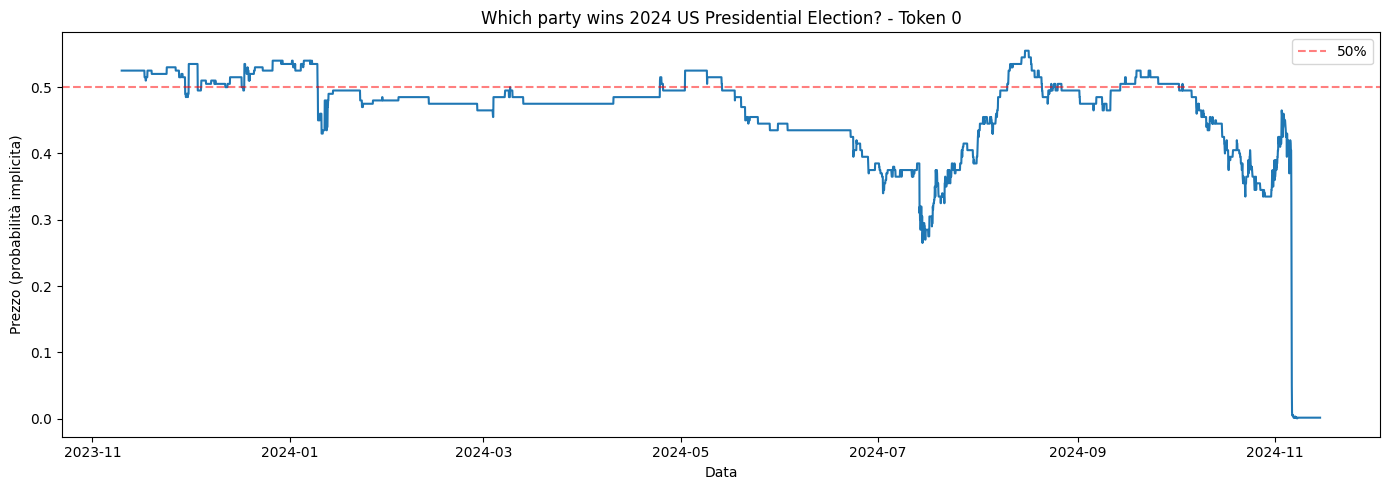

Token 0 ha perso (prezzo finale 0.0015) -> era il token Democrat


In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_history['timestamp'], df_history['price'])
plt.title('Which party wins 2024 US Presidential Election? - Token 0')
plt.xlabel('Data')
plt.ylabel('Prezzo (probabilità implicita)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50%')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Token 0 ha perso (prezzo finale {df_history['price'].iloc[-1]:.4f}) -> era il token Democrat")


In [40]:
from tqdm import tqdm
import time

def get_full_price_history(token_id, end_time, days_back=365, window_days=7):
    all_history = []
    end_ts = int(end_time.timestamp())
    window_sec = window_days * 24 * 3600
    current_end = end_ts
    current_start = current_end - window_sec
    cutoff = end_ts - (days_back * 24 * 3600)
    
    while current_end > cutoff:
        resp = requests.get(clob_url, params={
            "market": token_id,
            "startTs": current_start,
            "endTs": current_end,
            "fidelity": 100
        })
        if resp.status_code == 200:
            batch = resp.json().get('history', [])
            all_history = batch + all_history
        current_end = current_start
        current_start = current_end - window_sec
    
    return all_history

# Test su 10 mercati con tqdm
t0 = time.time()
results = []

for m in tqdm(all_resolved[:10], desc="Scaricando mercati"):
    close_time = pd.to_datetime(m['closedTime'], format='mixed', utc=True)
    token_yes = json.loads(m['clobTokenIds'])[0]
    
    history = get_full_price_history(token_yes, close_time, days_back=365)
    
    for row in history:
        results.append({
            'market_id': m['id'],
            'question': m['question'],
            'token_id': token_yes,
            't': row['t'],
            'price': row['p']
        })

elapsed = time.time() - t0
print(f"\n10 mercati in {elapsed:.1f}s -> stima per 4751: {elapsed/10*4751/60:.0f} minuti")
print(f"Righe raccolte: {len(results)}")

Scaricando mercati: 100%|███████████████████████| 10/10 [01:10<00:00,  7.08s/it]


10 mercati in 71.0s -> stima per 4751: 562 minuti
Righe raccolte: 0


In [41]:
# Filtro: solo mercati chiusi dopo il 2023 e con volume > 10k
df_filtered = df_markets[
    (df_markets['closedTime'] >= '2023-01-01') & 
    (df_markets['volume'] > 10000)
].sort_values('volume', ascending=False)

print(f"Mercati dopo filtro: {len(df_filtered)}")
print(f"\nDistribuzione per categoria:\n{df_filtered['category'].value_counts().head(10)}")
print(f"\nVolume min: ${df_filtered['volume'].min():,.0f}")
print(f"Volume max: ${df_filtered['volume'].max():,.0f}")

Mercati dopo filtro: 94

Distribuzione per categoria:
category
US-current-affairs    21
Crypto                 5
Ukraine & Russia       4
Global Politics        2
Pop-Culture            1
NFTs                   1
Business               1
Science                1
Coronavirus            1
Name: count, dtype: int64

Volume min: $10,178
Volume max: $8,828,319


In [42]:
# Test su 5 mercati filtrati per vedere quanti hanno dati
t0 = time.time()
results = []
has_data = 0

for m in tqdm(df_filtered.head(5).itertuples(), total=5, desc="Test"):
    close_time = m.closedTime
    token_yes = json.loads(m.clobTokenIds)[0]
    
    history = get_full_price_history(token_yes, close_time, days_back=365)
    
    if len(history) > 0:
        has_data += 1
        for row in history:
            results.append({
                'market_id': m.id,
                'question': m.question,
                'token_id': token_yes,
                't': row['t'],
                'price': row['p']
            })

elapsed = time.time() - t0
print(f"\n5 mercati in {elapsed:.1f}s -> stima per 94: {elapsed/5*94/60:.1f} minuti")
print(f"Mercati con dati: {has_data}/5")
print(f"Righe raccolte: {len(results)}")

Test: 100%|███████████████████████████████████████| 5/5 [00:36<00:00,  7.36s/it]


5 mercati in 36.8s -> stima per 94: 11.5 minuti
Mercati con dati: 4/5
Righe raccolte: 17097


In [43]:
results = []

for m in tqdm(df_filtered.itertuples(), total=len(df_filtered), desc="Scaricando storico"):
    close_time = m.closedTime
    token_yes = json.loads(m.clobTokenIds)[0]
    
    history = get_full_price_history(token_yes, close_time, days_back=365)
    
    for row in history:
        results.append({
            'market_id': m.id,
            'question': m.question,
            'category': m.category,
            'token_id': token_yes,
            'closedTime': m.closedTime,
            't': row['t'],
            'price': row['p']
        })

print(f"\nRighe totali: {len(results)}")

df_price_history = pd.DataFrame(results)
df_price_history['timestamp'] = pd.to_datetime(df_price_history['t'], unit='s', utc=True)
df_price_history.to_csv('price_history_resolved.csv', index=False)
print("Salvato: price_history_resolved.csv")

Scaricando storico:  33%|███████▌               | 31/94 [03:29<07:05,  6.76s/it]


TypeError: the JSON object must be str, bytes or bytearray, not float

In [44]:
results = []

for m in tqdm(df_filtered.itertuples(), total=len(df_filtered), desc="Scaricando storico"):
    try:
        close_time = m.closedTime
        token_yes = json.loads(m.clobTokenIds)[0]
        
        history = get_full_price_history(token_yes, close_time, days_back=365)
        
        for row in history:
            results.append({
                'market_id': m.id,
                'question': m.question,
                'category': m.category,
                'token_id': token_yes,
                'closedTime': m.closedTime,
                't': row['t'],
                'price': row['p']
            })
    except Exception as e:
        print(f"\nSkip {m.id}: {e}")
        continue

print(f"\nRighe totali: {len(results)}")
df_price_history = pd.DataFrame(results)
df_price_history['timestamp'] = pd.to_datetime(df_price_history['t'], unit='s', utc=True)
df_price_history.to_csv('price_history_resolved.csv', index=False)
print("Salvato: price_history_resolved.csv")

Scaricando storico:  33%|███████▌               | 31/94 [03:54<07:58,  7.59s/it]


Skip 240413: the JSON object must be str, bytes or bytearray, not float


Scaricando storico:  80%|██████████████████▎    | 75/94 [09:21<02:24,  7.60s/it]


Skip 247787: the JSON object must be str, bytes or bytearray, not float


Scaricando storico: 100%|███████████████████████| 94/94 [11:42<00:00,  7.47s/it]



Righe totali: 115409
Salvato: price_history_resolved.csv


In [45]:
print(df_price_history.shape)
print(df_price_history.dtypes)
print(f"\nMercati unici: {df_price_history['market_id'].nunique()}")
print(f"Range temporale: {df_price_history['timestamp'].min()} -> {df_price_history['timestamp'].max()}")
print(f"\nCandele per mercato:\n{df_price_history.groupby('question')['price'].count().sort_values(ascending=False).head(10)}")

(115409, 8)
market_id                  object
question                   object
category                   object
token_id                   object
closedTime    datetime64[ns, UTC]
t                           int64
price                     float64
timestamp     datetime64[ns, UTC]
dtype: object

Mercati unici: 65
Range temporale: 2022-12-15 02:40:37+00:00 -> 2024-11-14 22:40:03+00:00

Candele per mercato:
question
[Single Market] Will Kamala Harris win the U.S. 2024 Democratic presidential nomination?      5339
[Single Market] Will Pete Buttigieg win the U.S. 2024 Democratic presidential nomination?     5339
[Single Market] Will Joe Biden win the U.S. 2024 Democratic presidential nomination?          5339
[Single Market] Will Gavin Newsom win the U.S. 2024 Democratic presidential nomination?       5339
[Single Market] Will Hillary Clinton win the U.S. 2024 Democratic presidential nomination?    5339
[Single Market] Will Nikki Haley win the U.S. 2024 Republican presidential nomination

In [46]:
# Aggiungiamo days_to_close: giorni rimanenti alla chiusura al momento di ogni candela
df_price_history['days_to_close'] = (
    df_price_history['closedTime'] - df_price_history['timestamp']
).dt.total_seconds() / 86400

# Aggiungiamo anche l'outcome finale per ogni mercato (0 o 1)
final_prices = df_price_history.groupby('market_id')['price'].last().rename('final_price')
df_price_history = df_price_history.merge(final_prices, on='market_id')
df_price_history['outcome'] = (df_price_history['final_price'] > 0.5).astype(int)

print(df_price_history[['question', 'timestamp', 'price', 'days_to_close', 'outcome']].head(10))
print(f"\nOutcome distribution: {df_price_history['outcome'].value_counts().to_dict()}")

df_price_history.to_csv('price_history_resolved.csv', index=False)
print("\nCSV aggiornato salvato!")

                                          question                 timestamp  \
0  Which party wins 2024 US Presidential Election? 2023-11-10 01:00:03+00:00   
1  Which party wins 2024 US Presidential Election? 2023-11-10 02:40:02+00:00   
2  Which party wins 2024 US Presidential Election? 2023-11-10 04:20:02+00:00   
3  Which party wins 2024 US Presidential Election? 2023-11-10 06:00:02+00:00   
4  Which party wins 2024 US Presidential Election? 2023-11-10 07:40:02+00:00   
5  Which party wins 2024 US Presidential Election? 2023-11-10 09:20:02+00:00   
6  Which party wins 2024 US Presidential Election? 2023-11-10 11:00:03+00:00   
7  Which party wins 2024 US Presidential Election? 2023-11-10 12:40:02+00:00   
8  Which party wins 2024 US Presidential Election? 2023-11-10 14:20:02+00:00   
9  Which party wins 2024 US Presidential Election? 2023-11-10 16:00:03+00:00   

   price  days_to_close  outcome  
0  0.525     370.957095        0  
1  0.525     370.887662        0  
2  0.525     3